# Price Prediction Model

## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

df = pd.read_csv("../../data/processed/cleaned_listings.csv")
df.head()


,location,area,price,price_currency,status,new/resale,price_negotiable,description,security_deposit,facing,...,Swimming Pool,Sports Facility,Jogging Track,Landscaped Gardens,locality_score,Car Parking,city,property_type,price_per_sqft,amenity_count
0,Dhakoli,1300.0,2850000.0,INR,Unknown,0.0,0.0,This spacious 2 bhk builder floor is available...,1.0,Unknown,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,2192.31,0
1,Dhakoli,1400.0,3600000.0,INR,Unknown,0.0,0.0,It’s a 3 bhk builder floor situated in Dhakoli...,1.0,Unknown,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,2571.43,0
2,Dhakoli,1350.0,3690000.0,INR,Unknown,0.0,0.0,It has an area of 1350 sqft with a carpet area...,1.0,Northeast,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,2733.33,0
3,New Chandigarh Mohali,1200.0,10000000.0,INR,Unknown,0.0,0.0,It has a salable area of 1200 sqft and is avai...,1.0,Northeast,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,8333.33,0
4,Sunny Enclave,1008.0,3090000.0,INR,Unknown,1.0,0.0,This spacious 2 bhk builder floor is available...,1.0,East,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,3065.48,0


## Exploratory Analysis

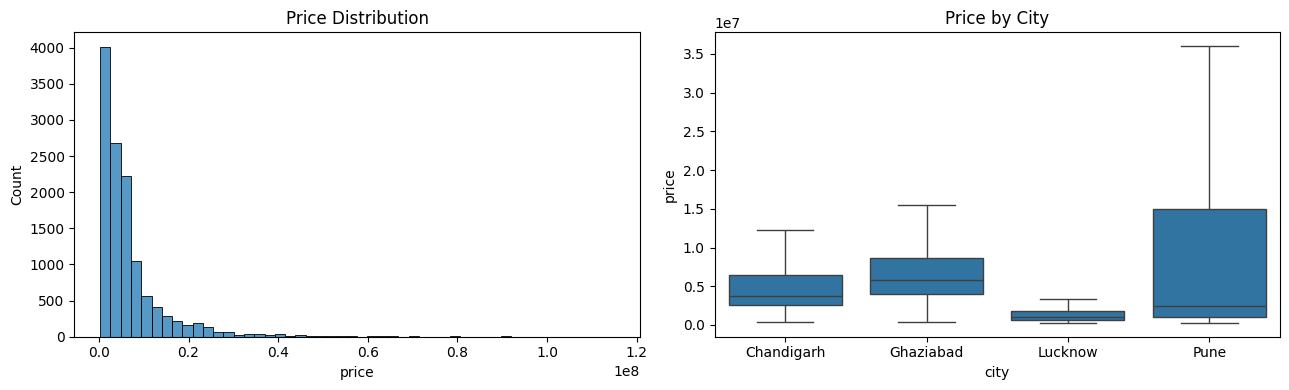

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(df["price"], bins=50, ax=axes[0]); axes[0].set_title("Price Distribution")
sns.boxplot(data=df, x="city", y="price", showfliers=False, ax=axes[1]); axes[1].set_title("Price by City")
plt.tight_layout(); plt.show()


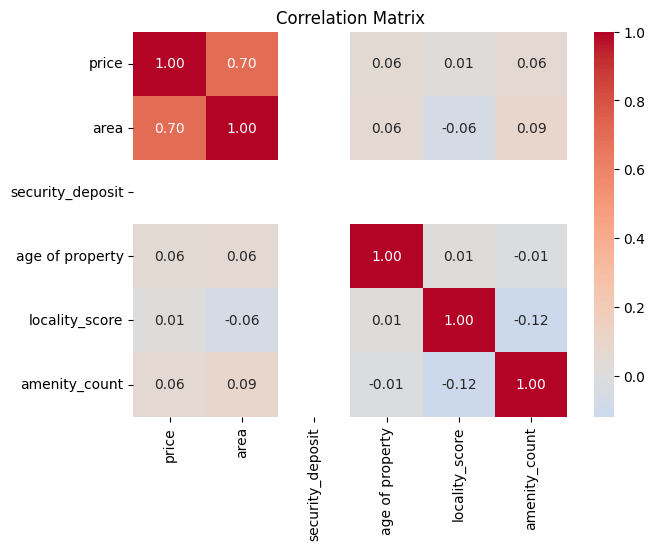

In [3]:
numeric_cols = ["price", "area", "security_deposit", "age of property", "locality_score", "amenity_count"]
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


## Feature Engineering

In [4]:
df["description"] = df["description"].fillna("")
desc = df["description"].str.lower()
for name, kw in {"desc_has_metro":"metro","desc_has_luxury":"luxury","desc_has_premium":"premium",
                  "desc_has_gated":"gated","desc_has_corner_plot":"corner plot","desc_has_spacious":"spacious"}.items():
    df[name] = desc.str.contains(kw, regex=False).astype(int)

cat_cols = ["city", "property_type", "facing", "status"]
desc_cols = [c for c in df.columns if c.startswith("desc_has_")]
num_cols = [c for c in df.columns if c not in cat_cols + desc_cols +
            ["price", "location", "description", "price_currency", "price_per_sqft"]]

model_df = pd.get_dummies(df.drop(columns=["description", "price_currency", "price_per_sqft"]),
                           columns=cat_cols, drop_first=True)
model_df["log_price"] = np.log1p(model_df["price"])
feature_cols = [c for c in model_df.columns if c not in ["price", "log_price", "location"]]


In [5]:
X = model_df[feature_cols + ["location"]]
y, y_price = model_df["log_price"], model_df["price"]
X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(X, y, y_price, test_size=0.2, random_state=42)

stats = X_train.assign(log_price=y_train).groupby("location")["log_price"].agg(["mean", "count"])
global_mean = y_train.mean()
loc_encoding = (stats["mean"] * stats["count"] + global_mean * 10) / (stats["count"] + 10)
X_train = X_train.assign(location_encoded=X_train["location"].map(loc_encoding)).drop(columns=["location"])
X_test = X_test.assign(location_encoded=X_test["location"].map(loc_encoding).fillna(global_mean)).drop(columns=["location"])
num_cols_final = num_cols + ["location_encoded"]

scaler = StandardScaler()
X_train[num_cols_final] = scaler.fit_transform(X_train[num_cols_final])
X_test[num_cols_final] = scaler.transform(X_test[num_cols_final])
feature_cols = list(X_train.columns)


## Model Training

In [6]:
log_min, log_max = y_train.min(), y_train.max()

def evaluate(model, name):
    model.fit(X_train, y_train)
    pred_price = np.expm1(np.clip(model.predict(X_test), log_min, log_max))
    r2 = r2_score(price_test, pred_price)
    mae = mean_absolute_error(price_test, pred_price)
    print(f"{name}: MAE={mae:,.0f}  R2={r2:.3f}")
    return model, r2, pred_price

lr_model, lr_r2, lr_pred = evaluate(LinearRegression(), "Linear Regression")

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), {"n_estimators":[100,200], "max_depth":[10,20]}, cv=2, scoring="r2")
rf_grid.fit(X_train, y_train)
rf_model, rf_r2, rf_pred = evaluate(rf_grid.best_estimator_, "Tuned Random Forest")

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42, max_depth=3), {"n_estimators":[100,150], "learning_rate":[0.05,0.1]}, cv=2, scoring="r2")
gb_grid.fit(X_train, y_train)
gb_model, gb_r2, gb_pred = evaluate(gb_grid.best_estimator_, "Tuned Gradient Boosting")

results_df = pd.DataFrame({"Model": ["Linear Regression", "Tuned Random Forest", "Tuned Gradient Boosting"],
                            "R2": [lr_r2, rf_r2, gb_r2]}).set_index("Model")
results_df


Linear Regression: MAE=2,443,743  R2=0.308
Tuned Random Forest: MAE=1,306,068  R2=0.820
Tuned Gradient Boosting: MAE=1,603,189  R2=0.804


,R2
Model,
Linear Regression,0.308128
Tuned Random Forest,0.820303
Tuned Gradient Boosting,0.804073


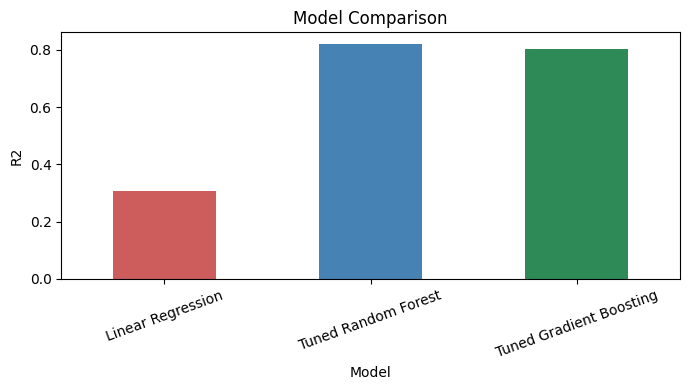

In [7]:
results_df["R2"].plot(kind="bar", figsize=(7,4), color=["indianred","steelblue","seagreen"])
plt.title("Model Comparison"); plt.ylabel("R2"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()


## Best Model

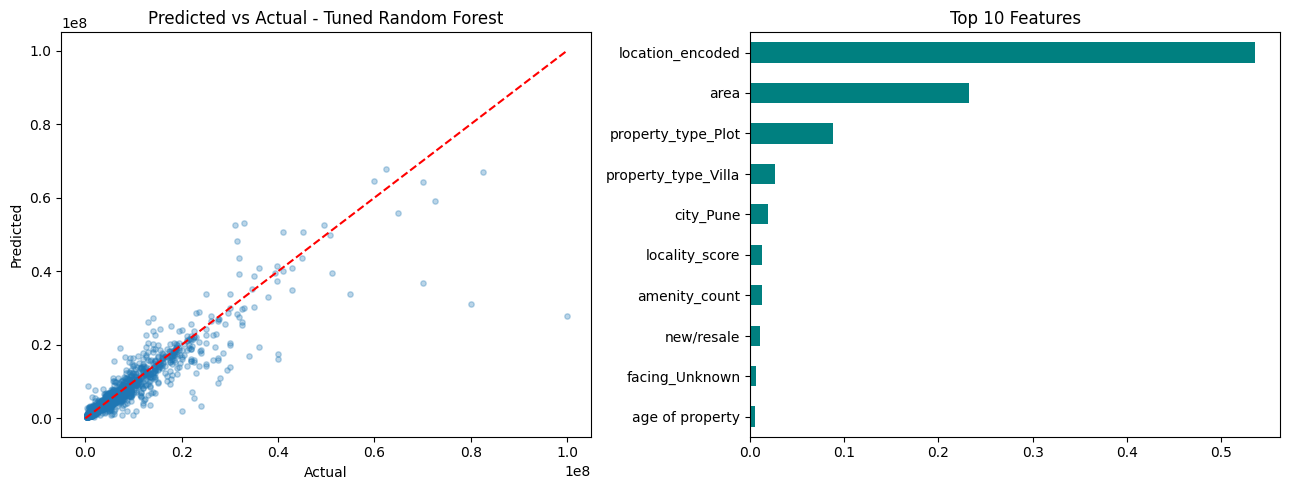

In [8]:
best_idx = results_df["R2"].idxmax()
best_model, best_pred = {"Linear Regression": (lr_model, lr_pred), "Tuned Random Forest": (rf_model, rf_pred),
                          "Tuned Gradient Boosting": (gb_model, gb_pred)}[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(13,5))
idx = np.random.choice(len(price_test), min(2000, len(price_test)), replace=False)
axes[0].scatter(price_test.values[idx], best_pred[idx], alpha=0.3, s=15)
axes[0].plot([0, price_test.max()], [0, price_test.max()], "r--")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted"); axes[0].set_title(f"Predicted vs Actual - {best_idx}")

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
    imp.sort_values().plot(kind="barh", ax=axes[1], color="teal")
    axes[1].set_title("Top 10 Features")
plt.tight_layout(); plt.show()


## Save Model

In [9]:
joblib.dump(best_model, "../../models/price_model.pkl")
joblib.dump(scaler, "../../models/price_scaler.pkl")
joblib.dump(feature_cols, "../../models/price_model_columns.pkl")
joblib.dump(num_cols_final, "../../models/price_numeric_columns.pkl")
joblib.dump(loc_encoding.to_dict(), "../../models/price_location_encoding.pkl")
joblib.dump(global_mean, "../../models/price_location_global_mean.pkl")
joblib.dump((log_min, log_max), "../../models/price_log_clip_range.pkl")
print("Saved:", best_idx)


Saved: Tuned Random Forest
